# Firefighting Device Detection with SimCLR

This notebook is self-contained for demonstration: it inspects the dataset, visualizes symbol crops, and can launch pretraining plus fine-tuning directly from notebook cells.

## Clarification about pretraining

The current project does **not** start from an externally pretrained SimCLR checkpoint.
It builds a fresh `resnet18` encoder, pretrains SimCLR on the firefighting symbol crops, and then fine-tunes a classifier on the labeled crops.

In [5]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'Data').exists() and (candidate / 'firefighting_simclr').exists():
            return candidate
    raise FileNotFoundError('Could not find the repository root from the current notebook working directory.')

ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT

WindowsPath('C:/Users/james/Firefighting_device_detection')

In [6]:
from collections import Counter
import json
import random

import matplotlib.pyplot as plt
from PIL import Image

from firefighting_simclr.data import build_label_mapping, extract_crop, load_split_records
from firefighting_simclr.notebook_utils import load_test_metrics, make_experiment_args, run_full_pipeline

DATA_DIR = ROOT / 'Data'
OUTPUT_DIR = ROOT / 'outputs' / 'notebook_demo'

print('Repo root:', ROOT)
print('Data directory exists:', DATA_DIR.exists())

Repo root: C:\Users\james\Firefighting_device_detection
Data directory exists: True


In [ ]:
def split_summary(split: str):
    records, _ = load_split_records(DATA_DIR, split)
    raw = json.loads((DATA_DIR / split / '_annotations.coco.json').read_text(encoding='utf-8'))
    counts = Counter(record.category_name for record in records)
    return {
        'split': split,
        'images': len(raw['images']),
        'annotations': len(records),
        'unique_classes': len(counts),
        'top_5_classes': counts.most_common(5),
    }
# show the summary of each split
for split in ['train', 'valid', 'test']:
    print(split_summary(split))

{'split': 'train', 'images': 102, 'annotations': 2606, 'unique_classes': 40, 'top_5_classes': [('24V-power-cord', 940), ('fire-fan-manual-control-line', 341), ('i-o-module', 151), ('bus-isolation-module', 136), ('coded-smoke-detector', 133)]}
{'split': 'valid', 'images': 28, 'annotations': 755, 'unique_classes': 33, 'top_5_classes': [('24V-power-cord', 295), ('fire-fan-manual-control-line', 74), ('bus-isolation-module', 48), ('coded-smoke-detector', 42), ('i-o-module', 37)]}
{'split': 'test', 'images': 18, 'annotations': 424, 'unique_classes': 30, 'top_5_classes': [('24V-power-cord', 149), ('fire-fan-manual-control-line', 59), ('bus-isolation-module', 25), ('coded-smoke-detector', 25), ('i-o-module', 22)]}


In [8]:
label_mapping, class_names = build_label_mapping(DATA_DIR)
train_records, _ = load_split_records(DATA_DIR, 'train')
valid_records, _ = load_split_records(DATA_DIR, 'valid')

train_ids = {record.category_id for record in train_records}
valid_only = sorted({record.category_name for record in valid_records if record.category_id not in train_ids})

print('Train-supported classes:', len(class_names))
print('Validation classes not seen in training:', valid_only)

Train-supported classes: 40
Validation classes not seen in training: ['explosion-proof-smoke-detector']


In [15]:
train_records

[CropRecord(image_path=WindowsPath('C:/Users/james/Firefighting_device_detection/Data/train/3-2-1b_PNG.rf.097ded96057ba3ded0c92d916e13e9b3.jpg'), bbox=(371.0, 300.0, 49.0, 34.0), category_id=31, category_name='pressure-switch-flow-switch-start-pump-line', split='train', image_id=0, annotation_id=0),
 CropRecord(image_path=WindowsPath('C:/Users/james/Firefighting_device_detection/Data/train/3-2-1b_PNG.rf.097ded96057ba3ded0c92d916e13e9b3.jpg'), bbox=(64.0, 13.0, 34.0, 27.0), category_id=1, category_name='24V-power-cord', split='train', image_id=0, annotation_id=1),
 CropRecord(image_path=WindowsPath('C:/Users/james/Firefighting_device_detection/Data/train/3-2-1b_PNG.rf.097ded96057ba3ded0c92d916e13e9b3.jpg'), bbox=(186.0, 13.0, 28.0, 26.0), category_id=1, category_name='24V-power-cord', split='train', image_id=0, annotation_id=2),
 CropRecord(image_path=WindowsPath('C:/Users/james/Firefighting_device_detection/Data/train/3-2-1b_PNG.rf.097ded96057ba3ded0c92d916e13e9b3.jpg'), bbox=(303.0, 1

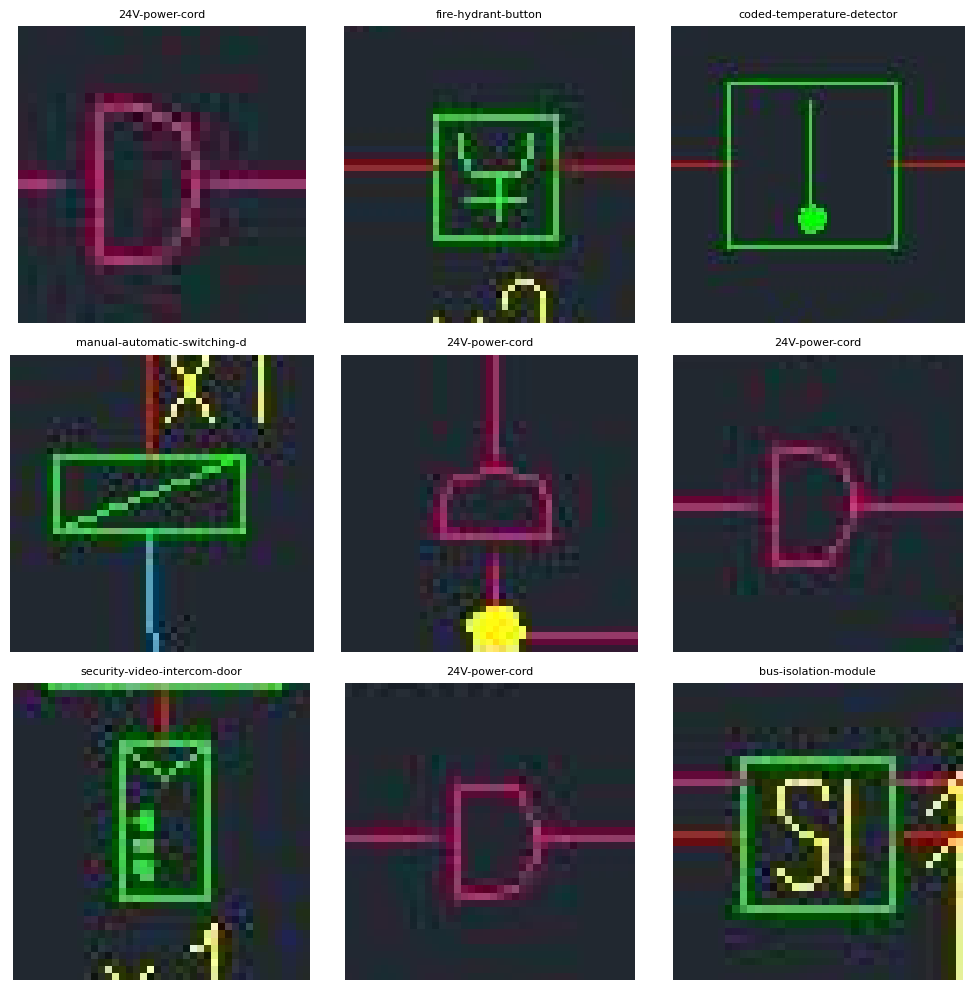

In [ ]:
# Show a few random samples of the training crops and their category names
sample_records = random.sample(train_records, 9)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, record in zip(axes.flat, sample_records):
    with Image.open(record.image_path) as image:
        crop = extract_crop(image.convert('RGB'), record.bbox, padding_ratio=0.15)
    ax.imshow(crop)
    ax.set_title(record.category_name[:28], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [24]:
crop.size

(39, 40)

## Notebook training workflow

The next cells build the same arguments that the CLI used before, but now the notebook calls the training functions directly.

Use the smoke-test config first. Once that runs, switch to the full config.

In [19]:
smoke_args = make_experiment_args(
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
    simclr_epochs=1,
    finetune_epochs=1,
    batch_size=32,
    device='cuda',
    amp=True,
)

vars(smoke_args)

{'data_dir': WindowsPath('C:/Users/james/Firefighting_device_detection/Data'),
 'output_dir': WindowsPath('C:/Users/james/Firefighting_device_detection/outputs/notebook_demo'),
 'backbone': 'resnet18',
 'image_size': 96,
 'batch_size': 32,
 'num_workers': 0,
 'crop_padding': 0.15,
 'device': 'cuda',
 'seed': 42,
 'weight_decay': 0.0001,
 'amp': True,
 'simclr_epochs': 1,
 'pretrain_lr': 0.0003,
 'temperature': 0.2,
 'projection_hidden_dim': 256,
 'projection_dim': 128,
 'finetune_epochs': 1,
 'finetune_lr': 0.001,
 'dropout': 0.2,
 'label_smoothing': 0.05,
 'linear_probe_epochs': 5}

In [20]:
# Uncomment the next line to actually run the smoke test from the notebook.
artifacts = run_full_pipeline(smoke_args)
artifacts

SimCLR epoch 1/1:   0%|          | 0/81 [00:00<?, ?it/s]

c:\Users\james\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Fine-tune epoch 1/1:   0%|          | 0/82 [00:00<?, ?it/s]

{'pretrain_dir': WindowsPath('C:/Users/james/Firefighting_device_detection/outputs/notebook_demo/pretrain'),
 'finetune_dir': WindowsPath('C:/Users/james/Firefighting_device_detection/outputs/notebook_demo/finetune'),
 'encoder_checkpoint': WindowsPath('C:/Users/james/Firefighting_device_detection/outputs/notebook_demo/pretrain/simclr_pretrain.pt'),
 'classifier_checkpoint': WindowsPath('C:/Users/james/Firefighting_device_detection/outputs/notebook_demo/finetune/best_symbol_classifier.pt')}

In [ ]:
full_args = make_experiment_args(
    data_dir=DATA_DIR,
    output_dir=ROOT / 'outputs' / 'final_run',
    device='cuda',
    amp=True,
)

vars(full_args)

In [ ]:
metrics_path = OUTPUT_DIR / 'finetune' / 'test_metrics.json'
if metrics_path.exists():
    metrics = load_test_metrics(OUTPUT_DIR)
    print({
        'loss': metrics['loss'],
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'num_samples': metrics['num_samples'],
    })
else:
    print(f'No metrics found yet at {metrics_path}')